# CW1 - Multimodal IMDB Analysis with Keras

## Introduction

In this assignment you will provided with a dataset containing a selection of films together with their posters in JPEG image format and their overviews in text format from the Internet Movie Database.

![Example](https://i.ibb.co/J3trT62/Screenshot-2024-09-22-214753.png)

You will be analysing this dataset by implementing and training two models: a **CNN** and an **LSTM**.

The CNN must classify film posters by the genre. Independently, the LSTM must classify film overviews by the genre. Finally, you will evaluate and critically comment your results in a short report. (Which of the two models was better at classifying films?)

## Structure of the assignment

This assignment is broken up into sections and you need to complete each section successively. The sections are the following:

1. Data Processing

  1.a. Image processing of the posters

  1.b. Natural language processing of the overviews

2. Models Definition

  2.a. CNN for the posters

  2.b. LSTM for the overviews

3. Models Training
4. Models Evaluation

In addition to this coding exercise, you must write a **2-page** report analysing and critically evaluating your model's results. Marks for the report will be awarded for depth of analysis and critical thinking skills. You should consider how well your model performs and WHY it does that—give specific examples and comment on their importance.

In [83]:
# Enter your module imports here, some modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import pathlib
import pandas as pd
from sklearn import model_selection
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense

In [84]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Data Processing



In [85]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

# This code will copy the images from your google drive into the colab file
# storage. Make sure the dataset is unzipped in your drive folder.
! mkdir /tmp/Multimodal_IMDB_dataset
! rsync -ah --info=progress2 /content/drive/MyDrive/Multimodal_IMDB_dataset/Images /tmp/Multimodal_IMDB_dataset/

mkdir: cannot create directory ‘/tmp/Multimodal_IMDB_dataset’: File exists
              0   0%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/7897)   


In [86]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell


# Load the csv with the sample IDs and genres
csv_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/IMDB_overview_genres.csv"
dataset = pd.read_csv(csv_loc)

# Split the dataset into training and testing
data_train, data_test = model_selection.train_test_split(dataset, test_size=0.2)

# Convert the labels to arrays
labels_train = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')
labels_test = np.array(data_test.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')

# List of the genre names
genres = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1).columns)

# List of overviews
overviews_train = np.array(data_train['Overview'])
overviews_test = np.array(data_test['Overview'])

# Build the file locations for the images
img_loc = "/tmp/Multimodal_IMDB_dataset/Images"

img_locs_train = np.array([[img_loc + '/' + id + '.jpg' for id in data_train['Id']]])
img_locs_test = [[img_loc + '/' + id + '.jpg' for id in data_test['Id']]]


# NOTICE: Provided function
# This function is provided to read in the image files from the folder
def parse_image(filename, label):
  image = tf.io.read_file(filename)
  image = tf.io.decode_jpeg(image)
  return image, label


### 1.a. Image processing of the posters

In [87]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Create the initial datasets of film posters
list_posters_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))
list_posters_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))

* **Create a function called ```img_process``` that converts the images to float32 datatype and resizes them to 64x64 pixels.**

In [88]:
# CodeGrade Tag Ex1a-i

def img_process(image, label):

    image = tf.image.resize(image, [64, 64])
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

* **Create a function called ```img_augment``` that applies appropriate data augmentations to the dataset of movie posters. Choose transformations that you believe will preserve the semantic validity of poster images.**

In [89]:
# CodeGrade Tag Ex1a-ii

def img_augment(image, label):

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    # Random saturation — colour shifts don't change genre meaning
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    # Clip to keep values in [0, 1] after jitter
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

* **Using the `tf.data` API, construct the training and validation poster datasets as follows:**
  - For the **training** dataset, apply `parse_image`, then `img_process`, then `img_augment`.
  - For the **validation** dataset, apply `parse_image` and `img_process` (no augmentation).
  - Batch the datasets with batch size `64`.
  - Use appropriate `tf.data` pipeline optimisations (such as shuffling the training data, parallel mapping, and prefetching).

In [90]:
# CodeGrade Tag Ex1a-iii

AUTOTUNE = tf.data.AUTOTUNE

posters_train_ds = (
    list_posters_train_ds
    .shuffle(buffer_size=len(data_train), reshuffle_each_iteration=True)
    .map(parse_image,  num_parallel_calls=AUTOTUNE)
    .map(img_process,  num_parallel_calls=AUTOTUNE)
    .map(img_augment,  num_parallel_calls=AUTOTUNE)
    .batch(64)
    .prefetch(AUTOTUNE)
)

posters_valid_ds = (
    list_posters_valid_ds
    .map(parse_image,  num_parallel_calls=AUTOTUNE)
    .map(img_process,  num_parallel_calls=AUTOTUNE)
    .batch(64)
    .prefetch(AUTOTUNE)
)

### 1.b. Natural Language processing of the overviews

In [91]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# Create the initial datasets of the film overviews
list_overviews_train_ds = tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))
list_overviews_valid_ds = tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))

* **Using the `tf.data` API, construct the training and validation overviews datasets as follows:**
  - Batch the datasets with batch size `32`.
  - Use appropriate `tf.data` pipeline optimisations such as shuffling the training data and prefetching.

In [92]:
# CodeGrade Tag Ex1b-i

overviews_train_ds = (
    list_overviews_train_ds
    .shuffle(buffer_size=len(overviews_train), reshuffle_each_iteration=True)
    .batch(32)
    .prefetch(AUTOTUNE)
)

overviews_valid_ds = (
    list_overviews_valid_ds
    .batch(32)
    .prefetch(AUTOTUNE)
)

* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the film overviews train data.

In [93]:
# CodeGrade Tag Ex1b-ii

VOCAB_SIZE = 10000

encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder.adapt(list_overviews_train_ds.map(lambda text, label: text))


#Complete here

* Print the first 200 words of the vocabulary you obtained.

In [94]:
# CodeGrade Tag Ex1b-iii

vocabulary = encoder.get_vocabulary()
print(vocabulary[:20])

['', '[UNK]', np.str_('a'), np.str_('the'), np.str_('to'), np.str_('of'), np.str_('and'), np.str_('in'), np.str_('his'), np.str_('is'), np.str_('an'), np.str_('with'), np.str_('her'), np.str_('for'), np.str_('on'), np.str_('he'), np.str_('their'), np.str_('who'), np.str_('by'), np.str_('from')]


## 2. Models Definition

### 2.a. CNN

In this question you will implement a custom Keras layer called `ResidualBlock`.  
This block will be used as the main building unit of the CNN in this section.

A residual block computes two tensors from the same input tensor `x`:

- a **main path** that learns a transformation $F(x)$, and
- a **skip path** that maps the input to a tensor $\mathrm{skip}(x)$ with the same shape as $F(x)$.

These two tensors are then added elementwise, and a final `ReLU` activation is applied:

$$
\mathrm{output} = \mathrm{ReLU}\big(F(x) + \mathrm{skip}(x)\big).
$$

More precisely, the block must have the following architecture.

* Main path

  The main path, corresponding to $F(x)$, must consist of the following layers in this exact order:

  - **3×3 convolution** with:
    - `filters = filters`
    - `strides = strides`
    - `padding = "same"`
    - `activation = "relu"`

  - **Dropout**

  - **3×3 convolution** with:
    - `filters = filters`
    - `strides = 1`
    - `padding = "same"`
    - **no activation function**

  - **Dropout**

* Skip path

  The skip path, corresponding to $\mathrm{skip}(x)$, must consist of a single layer:

  - **1×1 convolution** with:
    - `filters = filters`
    - `strides = strides`
    - `padding = "same"`


* Merge step

  The outputs of the two paths must then be combined as follows:

  - add the outputs elementwise, i.e. $F(x) + \mathrm{skip}(x)$;
  - apply a final ReLU activation to the sum (you can use `layers.ReLU` for this).


Graphically, the whole block will look like the following sketch:

  <img src="https://i.ibb.co/MkVXYFyg/Screenshot-2026-02-06-155017.png" width="300">


#### Implementation notes:
- Define the layers in `__init__` and implement the forward pass in `call`.
- Do not add any extra layers beyond those listed above.
- Recommended: you can use `kernel_initializer="he_normal"` for the convolutional layers, since this is often a good choice with ReLU activations, but this is not mandatory.


In [95]:
# CodeGrade Tag Ex2a-i

class ResidualBlock(layers.Layer):
    def __init__(self, filters, dropout=0.2, strides=1, name=None):
        super().__init__(name=name)

        # Main path

        self.conv1 =  Conv2D(filters, kernel_size=3, strides=strides,
                            padding="same", activation="relu",
                            kernel_initializer="he_normal")

        self.drop1 = Dropout(dropout)

        self.conv2 = Conv2D(filters, kernel_size=3, strides=1,
                            padding="same", activation=None,
                            kernel_initializer="he_normal")
        self.drop2 = Dropout(dropout)

        # Skip path
        self.skip = Conv2D(filters, kernel_size=1, strides=strides,
                           padding="same",
                           kernel_initializer="he_normal")

        # ReLU layer
        self.relu = layers.ReLU()

    def call(self, x, training=False):
        # Main path
        fx = self.conv1(x,  training=training)
        fx = self.drop1(fx, training=training)
        fx = self.conv2(fx, training=training)
        fx = self.drop2(fx, training=training)

        # Skip path
        skip_x = self.skip(x, training=training)

        # Merge: elementwise add then ReLU
        return self.relu(fx + skip_x)

Using the Keras Functional API, create a convolutional neural network (CNN) that uses the `ResidualBlock` layer you implemented in the previous question.  
This model takes `64×64` RGB movie posters as input and outputs 25 genre probabilities (multi-label classification).

A few important points to consider:

- The input images have shape `(64, 64, 3)`.

- Before the first residual block, apply a convolutional layer called `StemConv` with 32 filters, kernel size `3×3`, `padding="same"`, and `ReLU` activation.

- Use four residual blocks in total, with filter sizes `32, 64, 128, 128`.

- Apply `MaxPooling2D(pool_size=2)` after `Block1`, `Block2`, and `Block3`, but not after `Block4`, so that the spatial dimensions go `64 → 32 → 16 → 8`.

- After the last residual block, use `GlobalAveragePooling2D` (not `Flatten`) to obtain a single feature vector.

- Then use one dense layer `Dense(256, activation="relu")`, followed by `Dropout(0.5)`.

- The output layer must be `Dense(25, activation="sigmoid")` because this is a multi-label classification problem.

- Use the layer names given below so that your model summary matches.

- Do not add any extra top-level layers beyond those listed below.

The following table lists the exact top-level layers of the model:

| Layer name  | Layer type             | Output shape          | Notes                                          |
| ----------- | ---------------------- | --------------------- | ---------------------------------------------- |
| `Input`     | InputLayer             | `(None, 64, 64, 3)`   | Input posters                                  |
| `StemConv`  | Conv2D                 | `(None, 64, 64, 32)`  | 3×3 conv, 32 filters, **ReLU**, padding="same" |
| `Block1`    | ResidualBlock          | `(None, 64, 64, 32)`  | filters=32, dropout=0.2, strides=1             |
| `Pool1`     | MaxPool2D              | `(None, 32, 32, 32)`  | pool_size=2                                    |
| `Block2`    | ResidualBlock          | `(None, 32, 32, 64)`  | filters=64, dropout=0.2, strides=1             |
| `Pool2`     | MaxPool2D              | `(None, 16, 16, 64)`  | pool_size=2                                    |
| `Block3`    | ResidualBlock          | `(None, 16, 16, 128)` | filters=128, dropout=0.2, strides=1            |
| `Pool3`     | MaxPool2D              | `(None, 8, 8, 128)`   | pool_size=2                                    |
| `Block4`    | ResidualBlock          | `(None, 8, 8, 128)`   | filters=128, dropout=0.2, strides=1            |
| `GAP`       | GlobalAveragePooling2D | `(None, 128)`         | averages each 8×8 feature map                  |
| `Dense1`    | Dense                  | `(None, 256)`         | use ReLU as activation function                |
| `DropDense` | Dropout                | `(None, 256)`         | dropout rate = 0.5                             |
| `Output`    | Dense                  | `(None, 25)`          | **sigmoid**                                    |


Recommended: you may use `kernel_initializer="he_normal"` for the convolutional and hidden dense layers, since this often works well with ReLU activations, but this is not mandatory.

In [96]:
# CodeGrade Tag Ex2a-ii

def build_cnn(num_labels=25, input_shape=(64, 64, 3)):
    inputs = keras.Input(shape=input_shape, name="Input")

    x = Conv2D(32, kernel_size=3, padding="same", activation="relu",
               kernel_initializer="he_normal", name="StemConv")(inputs)

    # 64×64
    x = ResidualBlock(filters=32,  dropout=0.2, strides=1, name="Block1")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool1")(x)   # → 32×32

    # 32×32
    x = ResidualBlock(filters=64,  dropout=0.2, strides=1, name="Block2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool2")(x)   # → 16×16

    # 16×16
    x = ResidualBlock(filters=128, dropout=0.2, strides=1, name="Block3")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool3")(x)   # → 8×8

    # (no pooling after)
    x = ResidualBlock(filters=128, dropout=0.2, strides=1, name="Block4")(x)

    # Global average pooling
    x = layers.GlobalAveragePooling2D(name="GAP")(x)

    # Dense head
    x = Dense(256, activation="relu",
               kernel_initializer="he_normal", name="Dense1")(x)
    x = Dropout(0.5, name="DropDense")(x)
    outputs = Dense(num_labels, activation="sigmoid", name="Output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    return model

cnn_model = build_cnn()


* Print the model summary and confirm is has the same architecture as the one provided above.

In [98]:
# CodeGrade Tag Ex2a-iii

cnn_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ StemConv (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block1 (ResidualBlock)          │ (None, 64, 64, 32)     │        19,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block2 (ResidualBlock)          │ (None, 32, 32, 64)     │        57,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block3 (ResidualBlock)          │ (None, 16, 16, 128)    │       229,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block4 (ResidualBlock)          │ (None, 8, 8, 128)      │       311,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DropDense (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,873 (2.51 MB)

 Trainable params: 658,873 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [99]:
# CodeGrade Tag Ex2a-iv

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[Precision(), Recall()]
)


### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **265**. You should also set ```mask_zero=True```.

In [100]:
# CodeGrade Tag Ex2b-i

embedder = tf.keras.layers.Embedding(
    input_dim=len(encoder.get_vocabulary()),
    output_dim=265,
    mask_zero=True
)

* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:



  1.   encoder
  2.   embedder
  3.   biLSTM layer with 256 units, dropout 0.5, recurrent dropout 0.2 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   biLSTM layer with 128 units, dropout 0.5, recurrent dropout 0.2
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.8
  7.   dense output layer with 25 units and sigmoid activation function



In [101]:
# CodeGrade Tag Ex2b-ii

lstm_model = tf.keras.Sequential([
    encoder,
    embedder,
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(256, dropout=0.5, recurrent_dropout=0.2,
                             return_sequences=True)   # must be True to stack
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, dropout=0.5, recurrent_dropout=0.2)
    ),
    Dense(128, activation="relu"),
    Dropout(0.8),
    Dense(25, activation="sigmoid")
])

* Print the model summary and confirm it has the same architecture as the outline provided above.

In [102]:
# CodeGrade Tag Ex2b-iii

lstm_model.summary()
#Complete here

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss, the adam optimizer, and the accuracy metric

In [103]:
# CodeGrade Tag Ex2b-iv

#Complete here
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 3. Models Training

* **Create a Model Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss, for both the CNN and the LSTM**

In [104]:
# CodeGrade Tag Ex3a-i

checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cnn_callback = ModelCheckpoint(
    filepath=checkpoint_cnn_filepath,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

checkpoint_lstm_callback = ModelCheckpoint(
    filepath=checkpoint_lstm_filepath,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)


### 3.a. CNN training

* **Train the CNN model for 50 epochs, using the callbacks you made previously. Store the losses and metrics to use later.**

In [23]:
# CodeGrade Tag Ex3a

cnn_history = cnn_model.fit(
    posters_train_ds,
    validation_data=posters_valid_ds,
    epochs=50,
    callbacks=[checkpoint_cnn_callback]
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 1.6054 - precision: 0.1335 - recall: 0.3842
Epoch 1: val_loss improved from None to 0.45447, saving model to /content/checkpoint_cnn.weights.h5

Epoch 1: finished saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 254ms/step - loss: 0.7870 - precision: 0.1610 - recall: 0.3224 - val_loss: 0.4545 - val_precision: 0.5467 - val_recall: 0.2700
Epoch 2/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3558 - precision: 0.2724 - recall: 0.2506
Epoch 2: val_loss improved from 0.45447 to 0.43013, saving model to /content/checkpoint_cnn.weights.h5

Epoch 2: finished saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.3417 - precision: 0.2989 - recall: 0.2546 - val_loss: 0.4301 - val_precision: 0.5241 - val_recall: 0.3524
Epoch 3/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.3107 - precision: 0.3738 - recall: 0.2673
Epoch 3: val_loss improved from 0

### 3.b. LSTM training

* **Train the model for 20 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [24]:
# CodeGrade Tag Ex3b

lstm_history = lstm_model.fit(
    overviews_train_ds,
    validation_data=overviews_valid_ds,
    epochs=20,
    callbacks=[checkpoint_lstm_callback]
)

Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.1558 - loss: 0.4371
Epoch 1: val_loss improved from None to 0.23800, saving model to /content/checkpoint_lstm.weights.h5

Epoch 1: finished saving model to /content/checkpoint_lstm.weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 149s 805ms/step - accuracy: 0.1905 - loss: 0.3457 - val_accuracy: 0.2174 - val_loss: 0.2380
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.2302 - loss: 0.2645
Epoch 2: val_loss improved from 0.23800 to 0.22575, saving model to /content/checkpoint_lstm.weights.h5

Epoch 2: finished saving model to /content/checkpoint_lstm.weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 133s 775ms/step - accuracy: 0.2423 - loss: 0.2602 - val_accuracy: 0.2490 - val_loss: 0.2257
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.2846 - loss: 0.2416
Epoch 3: val_loss improved from 0.22575 to 0.22406, saving model to /content/checkpoint_lstm.weights.h5

Epoch 3: finished saving model to /content

### 3.c. Load the best weights

* Now, load the best weights from your checkpoints of both your models.

In [105]:
# CodeGrade Tag Ex3c

cnn_model.load_weights(checkpoint_cnn_filepath)
lstm_model.build(input_shape=(None,))
lstm_model.load_weights(checkpoint_lstm_filepath)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# 4. Models Evaluation

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

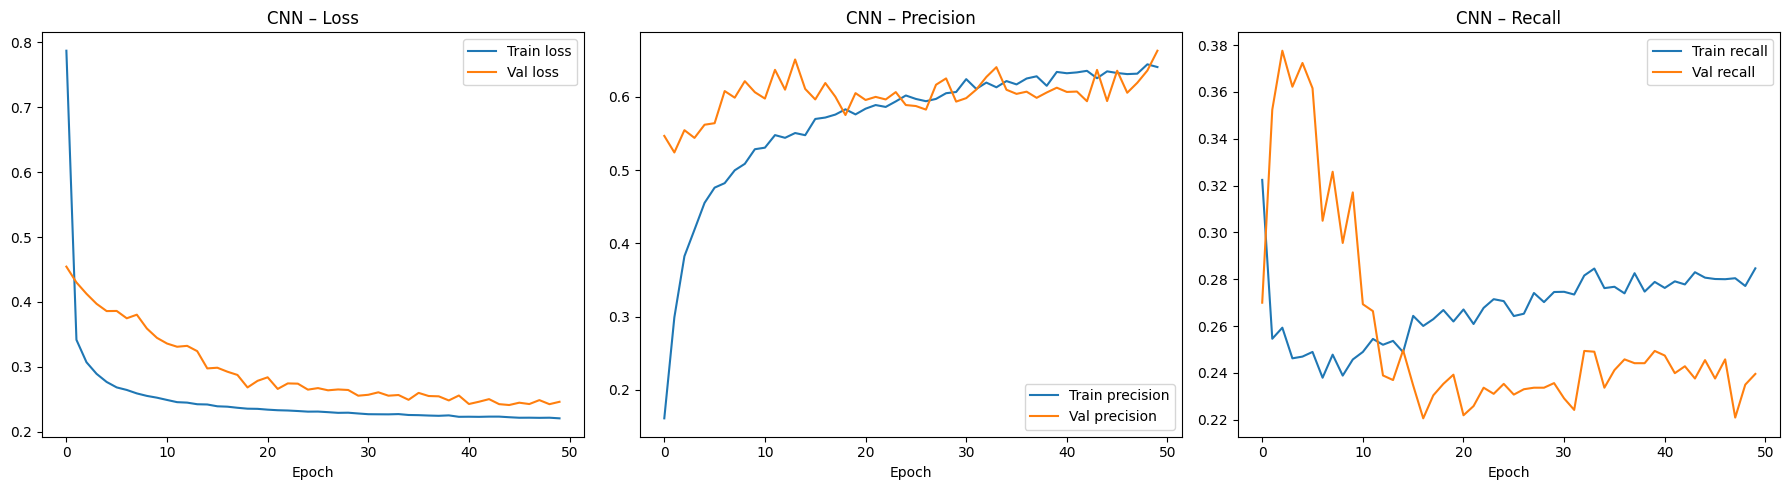

In [114]:
# CodeGrade Tag Ex4a-i
#Complete here

# Auto-detect correct key names (works in any session)
prec_key     = [k for k in cnn_history.history if 'precision' in k and 'val' not in k][0]
val_prec_key = [k for k in cnn_history.history if 'precision' in k and 'val'     in k][0]
rec_key      = [k for k in cnn_history.history if 'recall'    in k and 'val' not in k][0]
val_rec_key  = [k for k in cnn_history.history if 'recall'    in k and 'val'     in k][0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(cnn_history.history['loss'],     label='Train loss')
axes[0].plot(cnn_history.history['val_loss'], label='Val loss')
axes[0].set_title('CNN – Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(cnn_history.history[prec_key],     label='Train precision')
axes[1].plot(cnn_history.history[val_prec_key], label='Val precision')
axes[1].set_title('CNN – Precision'); axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[2].plot(cnn_history.history[rec_key],      label='Train recall')
axes[2].plot(cnn_history.history[val_rec_key],  label='Val recall')
axes[2].set_title('CNN – Recall'); axes[2].set_xlabel('Epoch')
axes[2].legend()
plt.tight_layout()
plt.show()

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

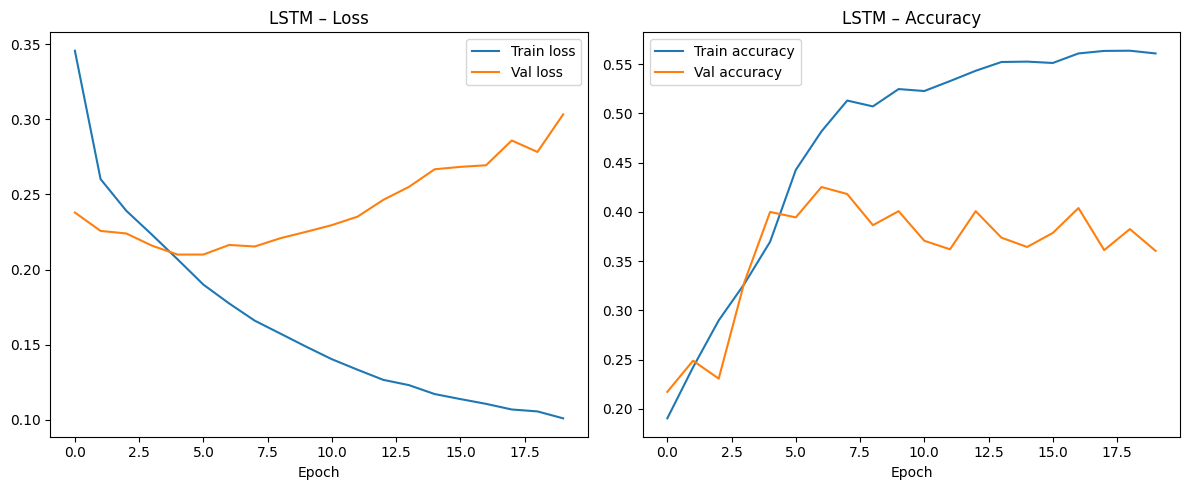

In [115]:
# CodeGrade Tag Ex4b-i

#Complete here

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(lstm_history.history['loss'],     label='Train loss')
axes[0].plot(lstm_history.history['val_loss'], label='Val loss')
axes[0].set_title('LSTM – Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(lstm_history.history['accuracy'],     label='Train accuracy')
axes[1].plot(lstm_history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('LSTM – Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.c. Produce examples for the report

* Choose a few films from the dataset, plot their posters and print their overviews. Use these example films to demonstrate the classification performance of the CNN model on their posters and of the LSTM model on their overview.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example film, the top three most probable genres predicted by the CNN and the top three most probable genres predicted by the LSTM with the ground truth genres.

* Include these examples in your report, and critically evaluate the performance of the model across the classes.

* Morevoer, you are allowed to add any other plot that could support your analysis, e.g. a confusion matrix.

**For this task, you can add new cells as you please.**

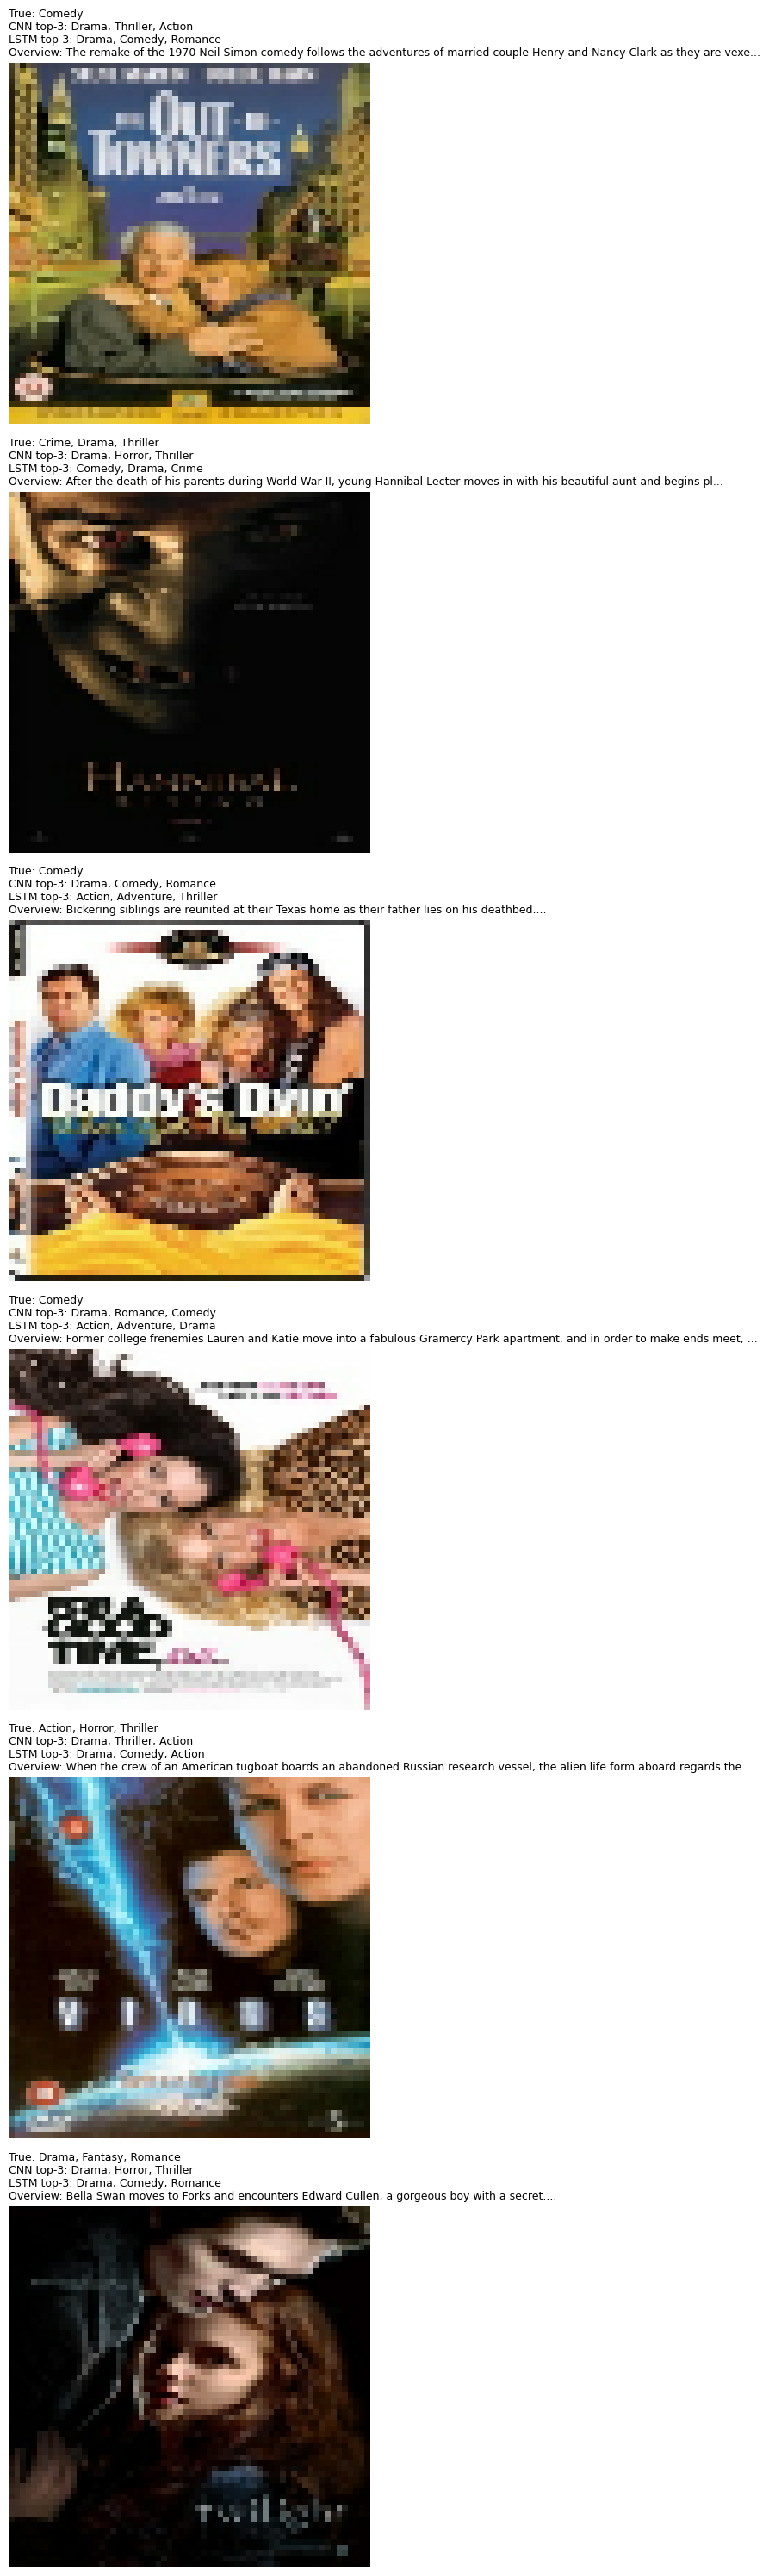

In [116]:
num_examples = 6
sample_indices = np.random.choice(len(data_test), num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(10, num_examples * 5))

for i, idx in enumerate(sample_indices):
    # ---- poster prediction (CNN) ----
    img_path = img_loc + '/' + data_test.iloc[idx]['Id'] + '.jpg'
    raw = tf.io.decode_jpeg(tf.io.read_file(img_path))
    proc_img, _ = img_process(raw, 0)
    cnn_pred = cnn_model.predict(tf.expand_dims(proc_img, 0), verbose=0)[0]
    top3_cnn = genres[np.argsort(cnn_pred)[::-1][:3]]

    # ---- overview prediction (LSTM) ----
    overview = data_test.iloc[idx]['Overview']
    lstm_pred = lstm_model.predict(tf.expand_dims(overview, 0), verbose=0)[0]
    top3_lstm = genres[np.argsort(lstm_pred)[::-1][:3]]

    # ---- ground truth ----
    true_genres = genres[labels_test[idx] == 1]

    # ---- plot ----
    axes[i].imshow(proc_img)
    axes[i].axis('off')
    axes[i].set_title(
        f"True: {', '.join(true_genres)}\n"
        f"CNN top-3: {', '.join(top3_cnn)}\n"
        f"LSTM top-3: {', '.join(top3_lstm)}\n"
        f"Overview: {overview[:120]}...",
        fontsize=9, loc='left'
    )

plt.tight_layout()
plt.show()

In [117]:
print(cnn_history.history.keys())

dict_keys(['loss', 'precision', 'recall', 'val_loss', 'val_precision', 'val_recall'])
